# B+ → π+ π+ π−: adaptive normalization grid diagnostic

This notebook visualizes the **actual adaptive Gauss–Legendre grid logic** used by `DalitzPlotFitter` when the narrow `omega(782)` is present in the symmetrized $\pi^+\pi^-$ amplitudes.

It is intentionally a diagnostic notebook: it does **not** call `model.normalization_sample`, so it does not materialize the full JAX normalization sample on the accelerator. Instead it uses the same axis segmentation and Gauss–Legendre nodes as the production integrator and applies the same Dalitz physical mask in small CPU chunks.

The default setup matches notebook 24 and the log message

```text
m13: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV
```


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel,
    DecayModel,
    RealImag,
    RelativisticBreitWigner,
    Resonance,
)
from dalitzplotfitter.integration import AdaptiveDalitzGaussLegendreGrid
from dalitzplotfitter.integration.gauss_legendre import _scaled_legendre, _s13_limits_numpy

channel = DecayChannel("B+", ("pi+", "pi+", "pi-"))

OMEGA_MASS = 0.78265
OMEGA_WIDTH = 0.00849

# A minimal model is enough to recover the exact narrow-band detection.
# Broad components do not alter the adaptive segmentation.
probe_model = DecayModel(
    channel,
    [
        Resonance(
            "omega782", (0, 2), RealImag(1.0, 0.0),
            mass=OMEGA_MASS,
            width=OMEGA_WIDTH,
            spin=1,
            lineshape=RelativisticBreitWigner(),
            resonance_radius=4.0,
            parent_radius=4.0,
        )
    ],
    normalize_components=False,
    normalization_method="gauss-legendre",
)

scheme = probe_model.normalization_scheme
scheme


{'method': 'gauss-legendre',
 'adaptive': True,
 'internal_coordinates': 'm13-m23',
 'narrow_resonances': {'m12': (),
  'm13': ((0.78265, 0.00849),),
  'm23': ((0.78265, 0.00849),)},
 'm13_segments': (AdaptiveAxisSegment(low=0.27914078000000003, high=0.7402, order=93, target_width=0.005, narrow=False),
  AdaptiveAxisSegment(low=0.7402, high=0.8251, order=300, target_width=0.000283, narrow=True),
  AdaptiveAxisSegment(low=0.8251, high=5.139839609999999, order=863, target_width=0.005, narrow=False)),
 'm23_segments': (AdaptiveAxisSegment(low=0.27914078000000003, high=0.7402, order=93, target_width=0.005, narrow=False),
  AdaptiveAxisSegment(low=0.7402, high=0.8251, order=300, target_width=0.000283, narrow=True),
  AdaptiveAxisSegment(low=0.8251, high=5.139839609999999, order=863, target_width=0.005, narrow=False)),
 'estimated_tensor_points': 1577536}

## Rebuild exactly the adaptive grid selected by `DecayModel`

The defaults are Laura++-style: 5 MeV coarse target spacing, narrow if $\Gamma \le 20$ MeV, a window of $m_0\pm5\Gamma$, and target spacing $\Gamma/100$ inside the narrow window.


In [2]:
narrow = scheme["narrow_resonances"]

grid = AdaptiveDalitzGaussLegendreGrid(
    mother_mass=channel.parent_mass,
    masses=channel.daughter_masses,
    m13_narrow_resonances=narrow["m13"],
    m23_narrow_resonances=narrow["m23"],
    bin_width=probe_model.normalization_bin_width,
    narrow_width=probe_model.normalization_narrow_width,
    window_n_widths=probe_model.normalization_narrow_window,
    binning_factor=probe_model.normalization_binning_factor,
)

def segment_table(segments, axis):
    return pd.DataFrame([
        {
            "axis": axis,
            "low_GeV": s.low,
            "high_GeV": s.high,
            "width_MeV": 1000.0 * (s.high - s.low),
            "target_spacing_MeV": 1000.0 * s.target_width,
            "order": s.order,
            "narrow": s.narrow,
        }
        for s in segments
    ])

segments = pd.concat([
    segment_table(grid.m13_segments, "m13"),
    segment_table(grid.m23_segments, "m23"),
], ignore_index=True)

display(segments)

n13 = sum(s.order for s in grid.m13_segments)
n23 = sum(s.order for s in grid.m23_segments)
fine_spacing = 1000.0 * OMEGA_WIDTH / probe_model.normalization_binning_factor

print(f"m13 nodes before tensor product: {n13:,}")
print(f"m23 nodes before tensor product: {n23:,}")
print(f"Estimated rectangular tensor points: {grid.estimated_tensor_points:,}")
print(f"omega narrow target spacing: {fine_spacing:.5f} MeV")
print(
    "omega refinement window: "
    f"[{OMEGA_MASS - 5*OMEGA_WIDTH:.5f}, {OMEGA_MASS + 5*OMEGA_WIDTH:.5f}] GeV"
)


,axis,low_GeV,high_GeV,width_MeV,target_spacing_MeV,order,narrow
0,m13,0.279141,0.74020,461.05922,5.000,93,False
1,m13,0.740200,0.82510,84.90000,0.283,300,True
2,m13,0.825100,5.13984,4314.73961,5.000,863,False
3,m23,0.279141,0.74020,461.05922,5.000,93,False
4,m23,0.740200,0.82510,84.90000,0.283,300,True
5,m23,0.825100,5.13984,4314.73961,5.000,863,False


m13 nodes before tensor product: 1,256
m23 nodes before tensor product: 1,256
Estimated rectangular tensor points: 1,577,536
omega narrow target spacing: 0.28300 MeV
omega refinement window: [0.74020, 0.82510] GeV


## One-dimensional Gauss–Legendre nodes

This shows how strongly the node density increases around the $\omega$. The nodes are not uniformly spaced inside a segment because they are Gauss–Legendre abscissae; `target_spacing` determines the segment order.


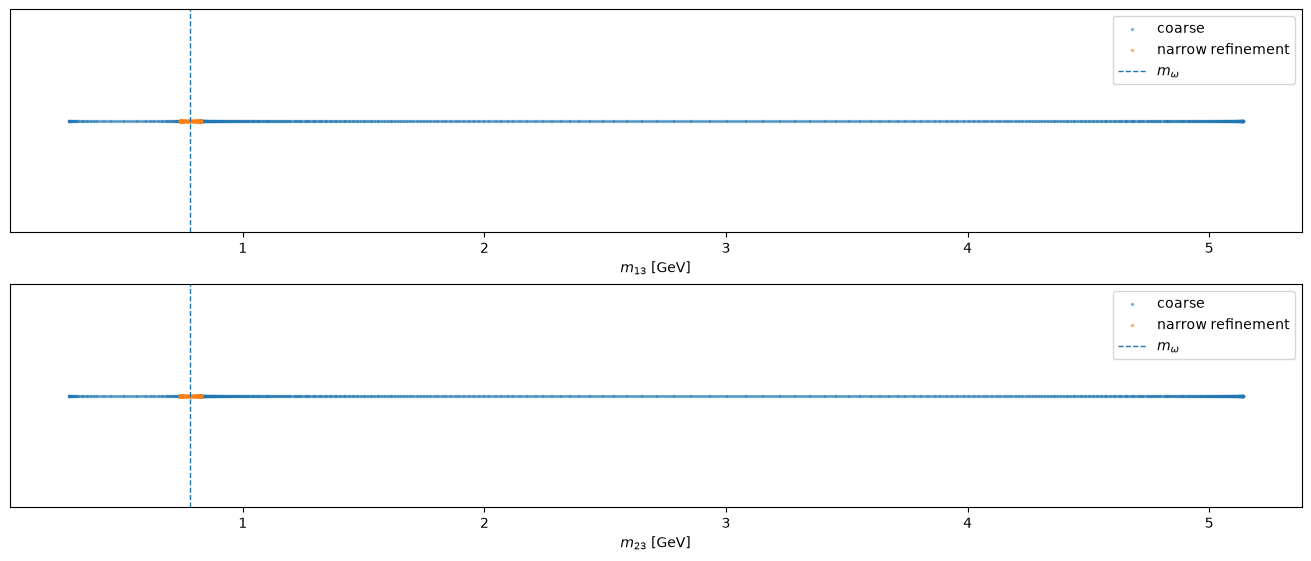

In [3]:
def axis_nodes(segments):
    nodes = []
    narrow_flags = []
    for segment in segments:
        x, _ = _scaled_legendre(segment.order, segment.low, segment.high)
        nodes.append(x)
        narrow_flags.append(np.full(x.shape, segment.narrow, dtype=bool))
    return np.concatenate(nodes), np.concatenate(narrow_flags)

m13_nodes, m13_is_narrow = axis_nodes(grid.m13_segments)
m23_nodes, m23_is_narrow = axis_nodes(grid.m23_segments)

fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), constrained_layout=True)

for ax, nodes, flags, label in [
    (axes[0], m13_nodes, m13_is_narrow, r"$m_{13}$"),
    (axes[1], m23_nodes, m23_is_narrow, r"$m_{23}$"),
]:
    ax.scatter(nodes[~flags], np.zeros(np.sum(~flags)), s=2, alpha=0.45, label="coarse")
    ax.scatter(nodes[flags], np.zeros(np.sum(flags)), s=2, alpha=0.55, label="narrow refinement")
    ax.axvline(OMEGA_MASS, linestyle="--", linewidth=1.0, label=r"$m_\omega$")
    ax.set_yticks([])
    ax.set_xlabel(label + " [GeV]")
    ax.legend(loc="upper right")

plt.show()


## Physical Dalitz mask and segment-pair cost

The production `AdaptiveDalitzGaussLegendreGrid.sample()` constructs a tensor-product mesh for each `(m13 segment, m23 segment)` pair and **only afterwards** applies the physical Dalitz mask. The diagnostic below uses the same physical test, but processes rows in small chunks so the notebook itself does not reproduce the large temporary allocation.


In [4]:
m1, m2, m3 = map(float, channel.daughter_masses)
M = float(channel.parent_mass)
INVARIANT_SUM = M**2 + m1**2 + m2**2 + m3**2
S12_MIN = (m1 + m2)**2
S12_MAX = (M - m3)**2
TOL = 64.0 * np.finfo(float).eps * max(1.0, M**2)

def physical_mask_masses(m13, m23):
    s13 = np.asarray(m13)**2
    s23 = np.asarray(m23)**2
    s12 = INVARIANT_SUM - s13 - s23
    s12_safe = np.clip(s12, S12_MIN, S12_MAX)
    low13, high13 = _s13_limits_numpy(
        s12_safe,
        mother_mass=M,
        masses=channel.daughter_masses,
    )
    return (
        (s12 >= S12_MIN - TOL)
        & (s12 <= S12_MAX + TOL)
        & (s13 >= low13 - TOL)
        & (s13 <= high13 + TOL)
    )

center_is_physical = bool(physical_mask_masses(
    np.array([[OMEGA_MASS]]), np.array([[OMEGA_MASS]])
)[0, 0])
print("Is (m13, m23) = (m_omega, m_omega) physical?", center_is_physical)

def collect_physical_plot_points_and_stats(grid, row_chunk=128, max_points_per_chunk=2500):
    plot_m13 = []
    plot_m23 = []
    rows = []

    for i, seg13 in enumerate(grid.m13_segments):
        x13, _ = _scaled_legendre(seg13.order, seg13.low, seg13.high)
        for j, seg23 in enumerate(grid.m23_segments):
            x23, _ = _scaled_legendre(seg23.order, seg23.low, seg23.high)
            candidate = int(x13.size * x23.size)
            nphysical = 0

            for start in range(0, x13.size, row_chunk):
                x13_chunk = x13[start:start + row_chunk]
                mm13, mm23 = np.meshgrid(x13_chunk, x23, indexing="ij")
                mask = physical_mask_masses(mm13, mm23)
                n_here = int(mask.sum())
                nphysical += n_here

                if n_here:
                    px = mm13[mask]
                    py = mm23[mask]
                    stride = max(1, math.ceil(n_here / max_points_per_chunk))
                    plot_m13.append(px[::stride])
                    plot_m23.append(py[::stride])

            # Production sample() creates four full float64 meshgrid arrays
            # (m13, m23, w13, w23) before the downstream derived arrays.
            four_meshgrids_mib = candidate * 4 * 8 / 2**20
            # A transparent proxy for the scale of a larger working set;
            # not a measured peak and not a claim about allocator overhead.
            proxy_10_float_plus_mask_mib = candidate * (10 * 8 + 1) / 2**20

            rows.append({
                "m13_segment": i,
                "m23_segment": j,
                "m13_narrow": seg13.narrow,
                "m23_narrow": seg23.narrow,
                "order13": seg13.order,
                "order23": seg23.order,
                "candidate_points": candidate,
                "physical_points": nphysical,
                "retained_fraction": nphysical / candidate if candidate else np.nan,
                "4_meshgrids_MiB": four_meshgrids_mib,
                "10_float_plus_mask_proxy_MiB": proxy_10_float_plus_mask_mib,
            })

    return (
        np.concatenate(plot_m13) if plot_m13 else np.empty(0),
        np.concatenate(plot_m23) if plot_m23 else np.empty(0),
        pd.DataFrame(rows),
    )

physical_m13_plot, physical_m23_plot, block_stats = collect_physical_plot_points_and_stats(grid)

display(block_stats.sort_values("candidate_points", ascending=False).reset_index(drop=True))

n_physical = int(block_stats.physical_points.sum())
print(f"Physical quadrature points after mask: {n_physical:,}")
print(f"Rectangular candidates before mask: {int(block_stats.candidate_points.sum()):,}")

# This was the important allocation in the old floating-dynamics/QMI cache:
# raw_norm = stack([component(normalization_grid) for component in components], axis=1)
N_COMPONENTS_QMI_MODEL = 6
raw_norm_mib = n_physical * N_COMPONENTS_QMI_MODEL * np.dtype(np.complex128).itemsize / 2**20
print()
print(f"Expected N x 6 complex128 raw_norm allocation: {raw_norm_mib:.2f} MiB")
print("Compare this directly with the allocator request in the OOM message.")


Is (m13, m23) = (m_omega, m_omega) physical? False


,m13_segment,m23_segment,m13_narrow,m23_narrow,order13,order23,candidate_points,physical_points,retained_fraction,4_meshgrids_MiB,10_float_plus_mask_proxy_MiB
0,2,2,False,False,863,863,744769,493467,0.662577,22.728546,57.531632
1,2,1,False,True,863,300,258900,224413,0.866794,7.901001,19.999409
2,1,2,True,False,300,863,258900,224413,0.866794,7.901001,19.999409
3,1,1,True,True,300,300,90000,0,0.000000,2.746582,6.952286
4,0,2,False,False,93,863,80259,45453,0.566329,2.449310,6.199817
5,2,0,False,False,863,93,80259,45453,0.566329,2.449310,6.199817
6,1,0,True,False,300,93,27900,0,0.000000,0.851440,2.155209
7,0,1,False,True,93,300,27900,0,0.000000,0.851440,2.155209
8,0,0,False,False,93,93,8649,0,0.000000,0.263947,0.668115


Physical quadrature points after mask: 1,033,199
Rectangular candidates before mask: 1,577,536

Expected N x 6 complex128 raw_norm allocation: 94.59 MiB
Compare this directly with the allocator request in the OOM message.


## The grid in the Dalitz plane

Grey/dense tensor points are shown **before** the physical mask (decimated only for display). The second set contains actual physical Gauss–Legendre nodes retained by the Dalitz mask, also decimated only for plotting. The dashed lines mark the two symmetrized $\omega$ bands.


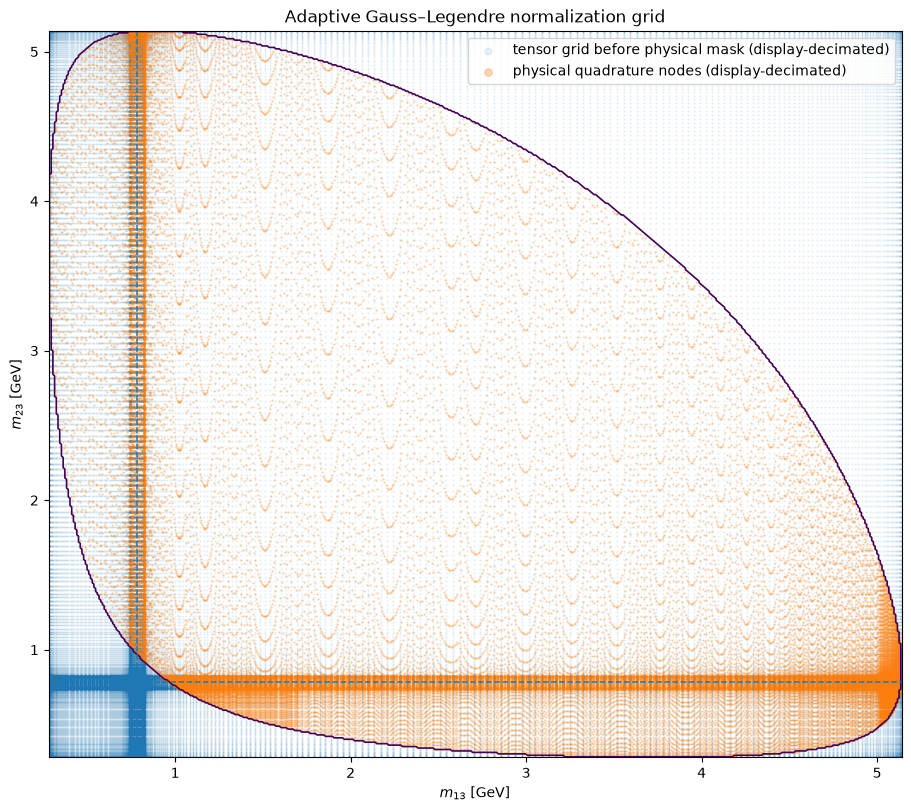

In [5]:
def decimated_candidate_points(grid, max_nodes_per_segment=180):
    px, py = [], []
    for seg13 in grid.m13_segments:
        x13, _ = _scaled_legendre(seg13.order, seg13.low, seg13.high)
        step13 = max(1, math.ceil(x13.size / max_nodes_per_segment))
        x13 = x13[::step13]
        for seg23 in grid.m23_segments:
            x23, _ = _scaled_legendre(seg23.order, seg23.low, seg23.high)
            step23 = max(1, math.ceil(x23.size / max_nodes_per_segment))
            x23 = x23[::step23]
            mm13, mm23 = np.meshgrid(x13, x23, indexing="ij")
            px.append(mm13.ravel())
            py.append(mm23.ravel())
    return np.concatenate(px), np.concatenate(py)

candidate_m13_plot, candidate_m23_plot = decimated_candidate_points(grid)

# A regular mask is used only to draw the physical boundary contour.
(m13_low, m13_high), (m23_low, m23_high) = grid.mass_ranges
boundary13 = np.linspace(m13_low, m13_high, 500)
boundary23 = np.linspace(m23_low, m23_high, 500)
bb13, bb23 = np.meshgrid(boundary13, boundary23, indexing="ij")
bbmask = physical_mask_masses(bb13, bb23)

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
ax.scatter(
    candidate_m13_plot, candidate_m23_plot,
    s=0.35, alpha=0.10, rasterized=True,
    label="tensor grid before physical mask (display-decimated)",
)
ax.scatter(
    physical_m13_plot, physical_m23_plot,
    s=0.45, alpha=0.30, rasterized=True,
    label="physical quadrature nodes (display-decimated)",
)
ax.contour(bb13, bb23, bbmask.astype(float), levels=[0.5], linewidths=1.2)
ax.axvline(OMEGA_MASS, linestyle="--", linewidth=1.1)
ax.axhline(OMEGA_MASS, linestyle="--", linewidth=1.1)
ax.set_xlabel(r"$m_{13}$ [GeV]")
ax.set_ylabel(r"$m_{23}$ [GeV]")
ax.set_title("Adaptive Gauss–Legendre normalization grid")
ax.legend(markerscale=8, loc="upper right")
plt.show()


## Zoom on the $\omega\times\omega$ tensor block

This is the key memory diagnostic. Because the same narrow resonance is refined on both axes, the integrator forms the Cartesian product of the two fine one-dimensional node sets. For this channel the point $(m_\omega,m_\omega)$ is outside the physical Dalitz region, but the tensor block is created **before** that fact is tested.


narrow m13 order: 300
narrow m23 order: 300
narrow × narrow tensor block: 90,000 candidate points


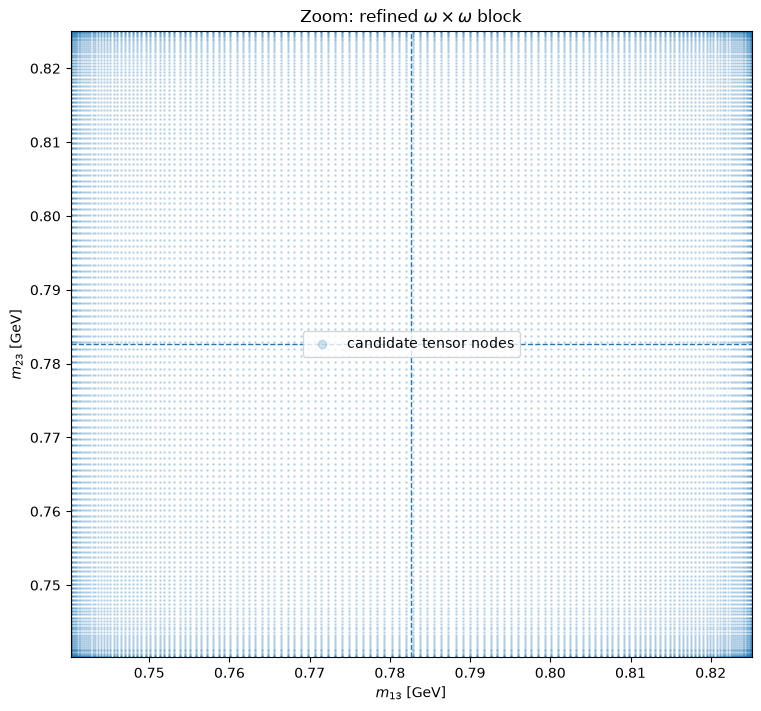

In [6]:
narrow13 = next(s for s in grid.m13_segments if s.narrow)
narrow23 = next(s for s in grid.m23_segments if s.narrow)
narrow_candidate_points = narrow13.order * narrow23.order

print(f"narrow m13 order: {narrow13.order:,}")
print(f"narrow m23 order: {narrow23.order:,}")
print(f"narrow × narrow tensor block: {narrow_candidate_points:,} candidate points")

zoom_low = min(narrow13.low, narrow23.low)
zoom_high = max(narrow13.high, narrow23.high)

fig, ax = plt.subplots(figsize=(7.5, 7), constrained_layout=True)
sel_candidate = (
    (candidate_m13_plot >= zoom_low) & (candidate_m13_plot <= zoom_high)
    & (candidate_m23_plot >= zoom_low) & (candidate_m23_plot <= zoom_high)
)
sel_physical = (
    (physical_m13_plot >= zoom_low) & (physical_m13_plot <= zoom_high)
    & (physical_m23_plot >= zoom_low) & (physical_m23_plot <= zoom_high)
)

ax.scatter(
    candidate_m13_plot[sel_candidate], candidate_m23_plot[sel_candidate],
    s=1.0, alpha=0.20, rasterized=True,
    label="candidate tensor nodes",
)
if np.any(sel_physical):
    ax.scatter(
        physical_m13_plot[sel_physical], physical_m23_plot[sel_physical],
        s=2.0, alpha=0.6, rasterized=True,
        label="physical nodes",
    )
ax.axvline(OMEGA_MASS, linestyle="--", linewidth=1.0)
ax.axhline(OMEGA_MASS, linestyle="--", linewidth=1.0)
ax.set_xlim(zoom_low, zoom_high)
ax.set_ylim(zoom_low, zoom_high)
ax.set_xlabel(r"$m_{13}$ [GeV]")
ax.set_ylabel(r"$m_{23}$ [GeV]")
ax.set_title(r"Zoom: refined $\omega\times\omega$ block")
ax.legend(markerscale=6)
plt.show()


## What to look for

1. The narrow window has target spacing $\Gamma/100 = 0.0849$ MeV, producing about 1000 Gauss–Legendre nodes per narrow axis segment.
2. Since identical-$\pi^+$ symmetrization puts the $\omega$ in both `m13` and `m23`, their tensor product contains about **one million candidate points** in the narrow×narrow block alone.
3. The production implementation builds the segment-pair mesh before applying the Dalitz mask. Therefore even an entirely or mostly unphysical crossing can create a large temporary working set.
4. `4_meshgrids_MiB` in the table is only the memory of `m13`, `m23`, `w13`, and `w23` float64 meshgrids. The subsequent `s13`, `s23`, `s12`, limits, mask, weights, and accelerator copies/temporaries make the true peak larger.

This notebook should therefore help distinguish **allocator fragmentation** from a genuine temporary-memory spike caused by the adaptive tensor-product construction.
